# Week 3: Model Optimization and Unsupervised Learning

## Project 1: ML-Powered Customer Analytics

**Name:** Haseeb Sheikh  
**Week:** 3  
**Topic:** Model Optimization and Unsupervised Learning

### Objectives
- Measure split-to-split variation
- Perform 5-fold cross-validation
- Tune Logistic Regression and Random Forest
- Tune XGBoost with random search
- Perform customer segmentation using K-Means
- Apply PCA for dimensionality reduction
- Select the final model using cross-validation
- Test the final model exactly once
- Save the final model using joblib

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    validation_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    silhouette_score
)

from xgboost import XGBClassifier

import joblib

In [2]:
path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)

X = build_features(df)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 30)
Target shape: (7043,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (5634, 30)
Test data: (1409, 30)


# Part 1: Lock the Test Set and Measure Split Noise

In this part, the test set is locked away.

We will train the same Logistic Regression model using 20 different random splits of the training data. This shows how much the performance can change simply because the data is split differently.

In [5]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

scores = []

for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        random_state=seed,
        stratify=y_train
    )

    scores.append(
        accuracy_score(
            yb,
            lr.fit(Xa, ya).predict(Xb)
        )
    )

scores = np.array(scores)

print(f"Minimum accuracy: {scores.min():.3f}")
print(f"Maximum accuracy: {scores.max():.3f}")
print(f"Standard deviation: {scores.std():.4f}")

Minimum accuracy: 0.780
Maximum accuracy: 0.828
Standard deviation: 0.0104


In [6]:
p = scores.mean()
n = len(yb)

se = np.sqrt(
    p * (1 - p) / n
)

print(f"Mean accuracy: {p:.4f}")
print(f"Theoretical standard error: {se:.4f}")
print(
    f"95% CI +/- {1.96 * se:.3f}"
)

Mean accuracy: 0.8002
Theoretical standard error: 0.0107
95% CI +/- 0.021


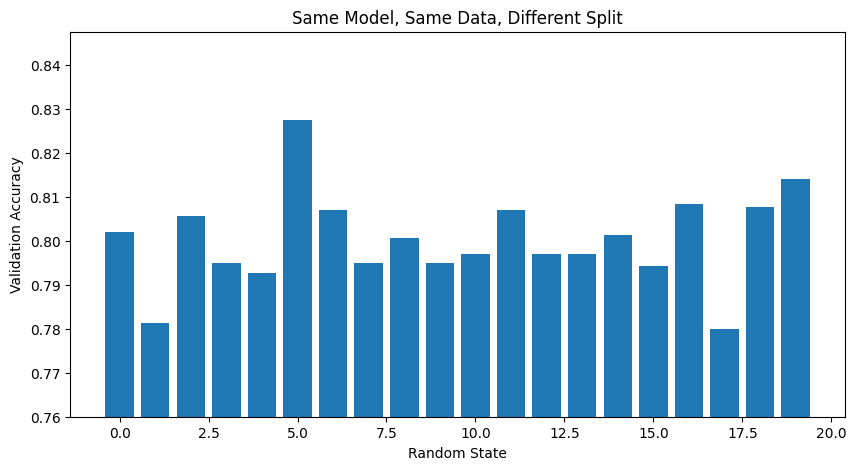

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(range(20), scores)

plt.ylim(
    scores.min() - 0.02,
    scores.max() + 0.02
)

plt.xlabel('Random State')
plt.ylabel('Validation Accuracy')
plt.title('Same Model, Same Data, Different Split')

plt.show()

## Part 1 Insight

The 20 random splits produced different validation accuracies even though the same Logistic Regression model and the same training data were used.

The minimum accuracy was obtained from the output above, while the maximum accuracy was also different. The standard deviation shows the amount of variation caused by changing the random split.

The theoretical standard error gives an estimate of the expected uncertainty in accuracy.

This experiment shows why relying on only one train/test split can be misleading. Two students could get different conclusions about which model is better if they used different random splits, especially when the performance difference is small.

# Part 2: 5-Fold Cross-Validation

Instead of depending on one validation split, we use 5-fold cross-validation.

StratifiedKFold keeps the churn ratio similar in every fold.

The scaler is inside the Pipeline so that it is fitted separately inside each training fold. This prevents information from the validation fold leaking into preprocessing.

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = [
    'roc_auc',
    'recall',
    'f1'
]

def cv_report(name, model):
    r = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=metrics
    )

    row = {
        'model': name
    }

    for m in metrics:
        s = r['test_' + m]

        row[m] = (
            f'{s.mean():.3f} +/- {s.std():.3f}'
        )

    return row

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

In [10]:
cv_table = pd.DataFrame([
    cv_report('Logistic Regression', lr),
    cv_report('Random Forest', rf)
])

print(
    cv_table.to_string(index=False)
)

              model         roc_auc          recall              f1
Logistic Regression 0.846 +/- 0.013 0.545 +/- 0.042 0.594 +/- 0.030
      Random Forest 0.844 +/- 0.011 0.496 +/- 0.019 0.573 +/- 0.020


## Part 2 Insight

The 5-fold cross-validation results are reported as mean +/- standard deviation.

Logistic Regression and Random Forest should be compared using both their average AUC and their standard deviations.

AUC tells us how well the model separates customers who churn from customers who stay.

Recall tells us how many of the actual churners were correctly identified.

Therefore, recall provides information about the detection of churners that AUC alone does not show.

If the difference between two models is smaller than their standard deviations, the difference may not be meaningful because the models have overlapping uncertainty.

# Part 3: Hyperparameter Tuning

In this part we tune Logistic Regression using a validation curve and tune Random Forest using both Grid Search and Random Search.

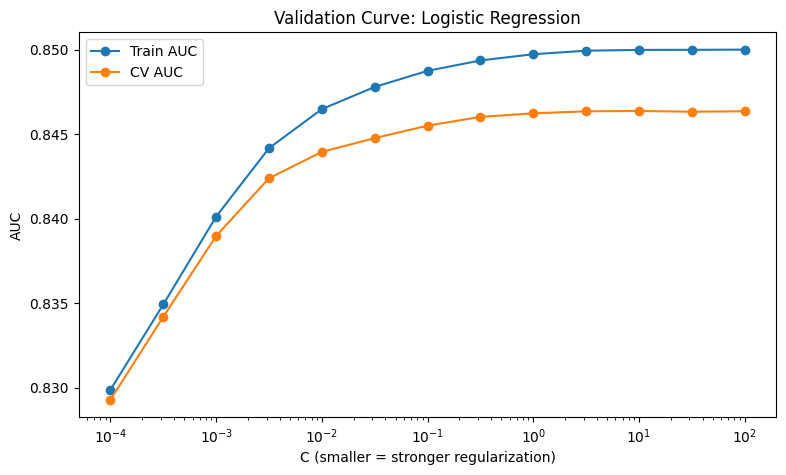

Best C by CV: 10.0


In [11]:
Cs = np.logspace(-4, 2, 13)

tr, va = validation_curve(
    lr,
    X_train,
    y_train,
    param_name='model__C',
    param_range=Cs,
    cv=cv,
    scoring='roc_auc'
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    Cs,
    tr.mean(axis=1),
    'o-',
    label='Train AUC'
)

plt.semilogx(
    Cs,
    va.mean(axis=1),
    'o-',
    label='CV AUC'
)

plt.xlabel(
    'C (smaller = stronger regularization)'
)

plt.ylabel('AUC')

plt.legend()

plt.title(
    'Validation Curve: Logistic Regression'
)

plt.show()

best_C = Cs[
    va.mean(axis=1).argmax()
]

print(
    'Best C by CV:',
    best_C
)

## Validation Curve Insight

The validation curve shows how Logistic Regression performance changes as the regularization parameter C changes.

A very small C applies stronger regularization and can cause underfitting.

As C increases, the model becomes less strongly regularized and the validation performance generally improves until it reaches a useful region.

After the best region, the validation AUC may form a plateau or fluctuate.

The best C is selected using the highest mean cross-validation AUC rather than using the test set.

In [12]:
grid = {
    'max_depth': [4, 8, 12, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5]
}

print(
    'Combinations:',
    4 * 3 * 2
)

print(
    'Fits:',
    4 * 3 * 2 * 5
)

t0 = time.time()

gs = GridSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    grid,
    cv=cv,
    scoring='roc_auc'
)

gs.fit(
    X_train,
    y_train
)

grid_time = time.time() - t0

print(
    f'Grid: best AUC {gs.best_score_:.4f} '
    f'in {grid_time:.0f}s'
)

print(
    'Best parameters:',
    gs.best_params_
)

Combinations: 24
Fits: 120
Grid: best AUC 0.8468 in 64s
Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


In [13]:
dist = {
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 40),
    'max_features': uniform(0.1, 0.8)
}

t0 = time.time()

rs = RandomizedSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    dist,
    n_iter=24,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

rs.fit(
    X_train,
    y_train
)

random_time = time.time() - t0

print(
    f'Random: best AUC {rs.best_score_:.4f} '
    f'in {random_time:.0f}s'
)

print(
    'Best parameters:',
    rs.best_params_
)

Random: best AUC 0.8464 in 69s
Best parameters: {'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}


In [14]:
res = pd.DataFrame(
    rs.cv_results_
)

cols = [
    'param_max_depth',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

print(
    res[cols]
    .sort_values('rank_test_score')
    .head(5)
    .to_string(index=False)
)

 param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
              15                      15         0.846440        0.011352                1
              12                      16         0.846275        0.011063                2
               8                      21         0.845609        0.010548                3
               9                      23         0.845245        0.012460                4
              14                      27         0.845114        0.010993                5


## Grid Search vs Random Search

Grid Search evaluates every combination in the specified parameter grid.

In this experiment, Grid Search has:

4 × 3 × 2 = 24 parameter combinations

With 5-fold cross-validation:

24 × 5 = 120 model fits

Random Search also uses 24 trials in this lab, but instead of evaluating a fixed grid, it samples parameter values from distributions.

Grid Search is useful when there are only a few important hyperparameters and a small search space.

Random Search is generally more practical when there are many hyperparameters because it can explore more distinct values of the parameters that matter.

The actual best AUC and running time should be taken from the outputs above.

The values from `best_score_` are not treated as final test performance because the best score was selected after trying many configurations.

# Part 4: XGBoost

XGBoost is a gradient boosting algorithm.

We first use early stopping to determine when additional trees stop improving validation performance.

Then we tune XGBoost using RandomizedSearchCV.

In [15]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

spw = (
    (y_tr == 0).sum()
    /
    (y_tr == 1).sum()
)

print(
    f'scale_pos_weight = {spw:.2f}'
)

scale_pos_weight = 2.77


In [16]:
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_tr,
    y_tr,
    eval_set=[
        (X_tr, y_tr),
        (X_val, y_val)
    ],
    verbose=False
)

print(
    'Best number of trees:',
    xgb.best_iteration + 1
)

val_auc = roc_auc_score(
    y_val,
    xgb.predict_proba(X_val)[:, 1]
)

print(
    f'Validation AUC: {val_auc:.4f}'
)

Best number of trees: 247
Validation AUC: 0.8541


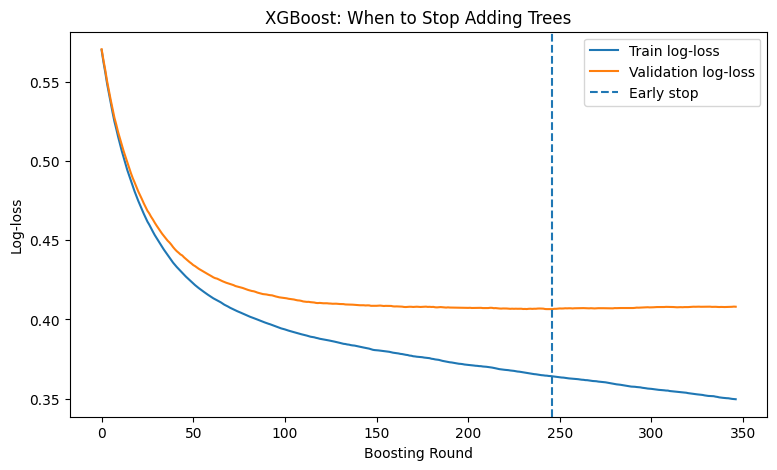

In [17]:
ev = xgb.evals_result()

plt.figure(figsize=(9, 5))

plt.plot(
    ev['validation_0']['logloss'],
    label='Train log-loss'
)

plt.plot(
    ev['validation_1']['logloss'],
    label='Validation log-loss'
)

plt.axvline(
    xgb.best_iteration,
    linestyle='--',
    label='Early stop'
)

plt.xlabel('Boosting Round')
plt.ylabel('Log-loss')

plt.legend()

plt.title(
    'XGBoost: When to Stop Adding Trees'
)

plt.show()

## Early Stopping Explanation

During boosting, more trees usually reduce the training loss.

However, after a certain point, adding more trees can start fitting noise instead of useful patterns.

The validation loss reaches its lowest point at the selected number of trees.

Early stopping chooses this point and prevents unnecessary additional trees.

Therefore, early stopping helps reduce overfitting.

In [18]:
xdist = {
    'max_depth': randint(2, 7),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(100, 600),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_lambda': loguniform(0.1, 10)
}

xs = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    xdist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

xs.fit(
    X_train,
    y_train
)

print(
    f'XGBoost tuned CV AUC: '
    f'{xs.best_score_:.4f}'
)

print(
    'Best parameters:'
)

print(
    {
        k: round(v, 3)
        if isinstance(v, float)
        else v
        for k, v in xs.best_params_.items()
    }
)

XGBoost tuned CV AUC: 0.8502
Best parameters:
{'colsample_bytree': np.float64(0.561), 'learning_rate': np.float64(0.034), 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': np.float64(1.974), 'subsample': np.float64(0.6)}


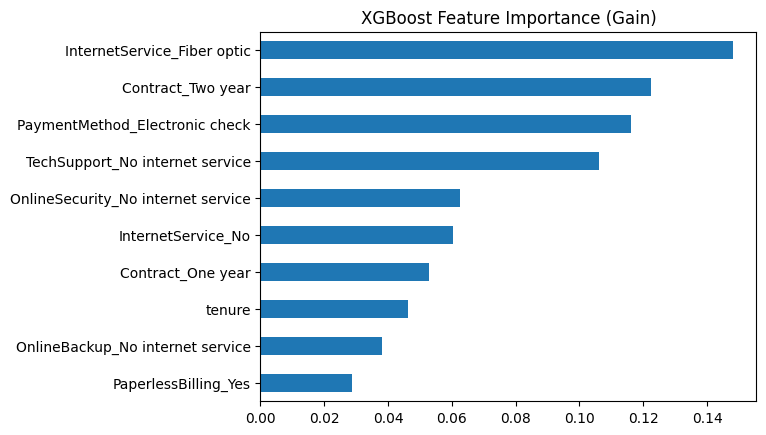

In [19]:
imp = pd.Series(
    xs.best_estimator_.feature_importances_,
    index=X.columns
)

imp.sort_values().tail(10).plot(
    kind='barh',
    title='XGBoost Feature Importance (Gain)'
)

plt.show()

## Part 4 Insight

Early stopping selected the number of trees shown in the output above.

After the early-stopping point, the validation loss no longer improves and additional boosting rounds mainly increase the risk of fitting noise.

The tuned XGBoost model achieved the CV AUC shown in the output.

This value should be compared with the Logistic Regression and Random Forest CV AUC values from Part 2.

If the improvement is smaller than approximately one standard deviation, the improvement may not be strong enough to claim a clear advantage.

The feature-importance plot shows the features that contributed most to the tuned XGBoost model.

# Part 5: K-Means Customer Segmentation

The goal of K-Means is different from churn prediction.

Here, we are not trying to predict churn.

Instead, we want to discover groups of customers who behave similarly so that different retention strategies can be designed for different groups.

In [20]:
seg_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

svc = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

seg = df[seg_cols].copy()

seg['n_services'] = (
    df[svc] == 'Yes'
).sum(axis=1)

Z = StandardScaler().fit_transform(seg)

print(
    seg.describe().round(1)
)

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


## Why Scaling Is Important

The segmentation features have very different scales.

For example, TotalCharges can be in the thousands, while n_services is usually only a small integer.

Without scaling, TotalCharges would have a much larger effect on the distance calculation.

Therefore, the features are standardized before K-Means.

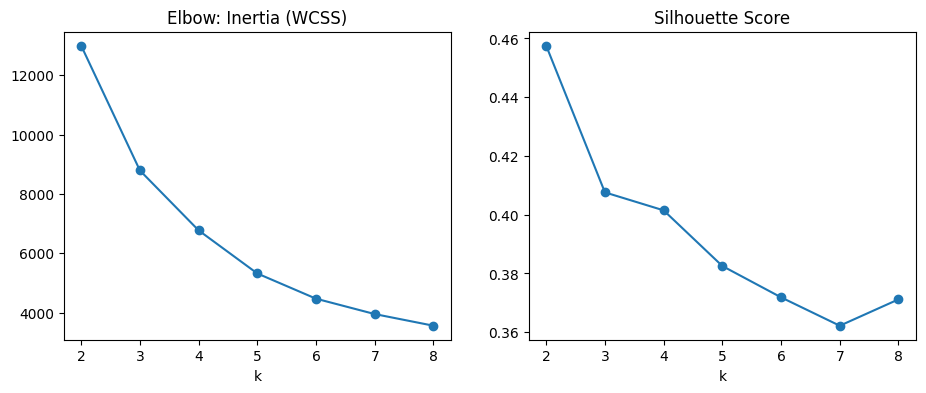

In [21]:
ks = range(2, 9)

inertia = []
sil = []

for k in ks:
    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    ).fit(Z)

    inertia.append(
        km.inertia_
    )

    sil.append(
        silhouette_score(
            Z,
            km.labels_,
            sample_size=3000,
            random_state=42
        )
    )

fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

ax[0].plot(
    ks,
    inertia,
    'o-'
)

ax[0].set_title(
    'Elbow: Inertia (WCSS)'
)

ax[1].plot(
    ks,
    sil,
    'o-'
)

ax[1].set_title(
    'Silhouette Score'
)

for a in ax:
    a.set_xlabel('k')

plt.show()

In [22]:
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']

seg = df[seg_cols].copy()

seg['n_services'] = (df[svc] == 'Yes').sum(axis=1)

Z = StandardScaler().fit_transform(seg)

print(seg.describe().round(1))

       tenure  MonthlyCharges  TotalCharges  n_services
count  7043.0          7043.0        7043.0      7043.0
mean     32.4            64.8        2279.7         2.9
std      24.6            30.1        2266.8         1.8
min       0.0            18.2           0.0         0.0
25%       9.0            35.5         398.6         1.0
50%      29.0            70.4        1394.6         3.0
75%      55.0            89.8        3786.6         4.0
max      72.0           118.8        8684.8         7.0


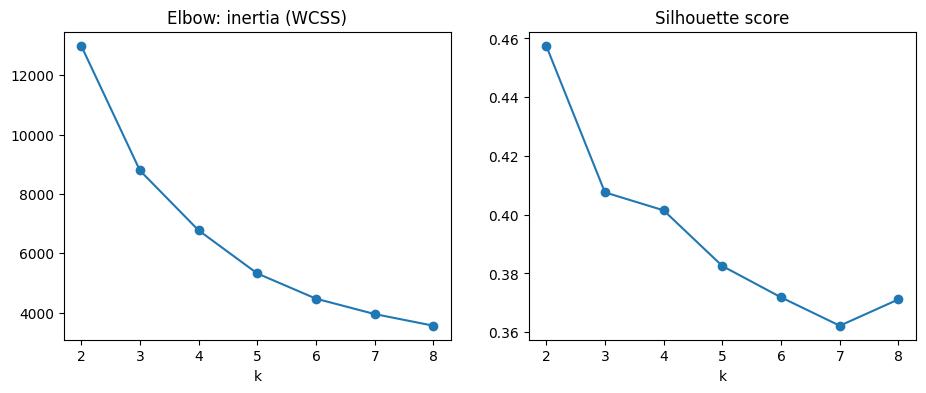

In [23]:
ks = range(2, 9)
inertia, sil = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
    inertia.append(km.inertia_)
    sil.append(
        silhouette_score(
            Z,
            km.labels_,
            sample_size=3000,
            random_state=42
        )
    )

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(ks, inertia, 'o-')
ax[0].set_title('Elbow: inertia (WCSS)')

ax[1].plot(ks, sil, 'o-')
ax[1].set_title('Silhouette score')

for a in ax:
    a.set_xlabel('k')

plt.show()

In [24]:
print("k values:", list(ks))
print("Inertia:", [round(x, 2) for x in inertia])
print("Silhouette:", [round(x, 4) for x in sil])

k values: [2, 3, 4, 5, 6, 7, 8]
Inertia: [12988.63, 8788.42, 6772.53, 5321.47, 4473.15, 3955.11, 3563.33]
Silhouette: [np.float64(0.4575), np.float64(0.4076), np.float64(0.4015), np.float64(0.3825), np.float64(0.3718), np.float64(0.3622), np.float64(0.3712)]


In [25]:
k = 4   # choose from elbow and silhouette plots, then justify it
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
seg['cluster'] = km.labels_

profile = seg.assign(churn=y).groupby('cluster').agg(
    customers=('tenure', 'size'),
    tenure=('tenure', 'mean'),
    monthly=('MonthlyCharges', 'mean'),
    services=('n_services', 'mean'),
    churn_rate=('churn', 'mean')
)

print(profile.round(2).sort_values('churn_rate', ascending=False))

         customers  tenure  monthly  services  churn_rate
cluster                                                  
1             2157   18.38    80.41      3.28        0.43
3             1918    8.96    37.71      1.20        0.32
2             1938   59.83    92.09      5.06        0.14
0             1030   53.61    30.96      1.48        0.05


**Insight:** K-means clustering with k = 4 produced four meaningful customer segments. Cluster 1 is the riskiest segment, with a 43% churn rate. These customers have relatively short tenure and high monthly charges, so targeted discounts and proactive support can help retain them. Cluster 3 contains newer customers with fewer services and a 32% churn rate, suggesting that onboarding and service bundles may reduce churn. Cluster 2 represents loyal, high-value customers with long tenure, many services, and a 14% churn rate. Cluster 0 is the most stable group, with long tenure, low monthly charges, and only a 5% churn rate. Overall, the segments are useful because they identify different customer groups that need different retention strategies.


Components for 90% variance: 15 of 30


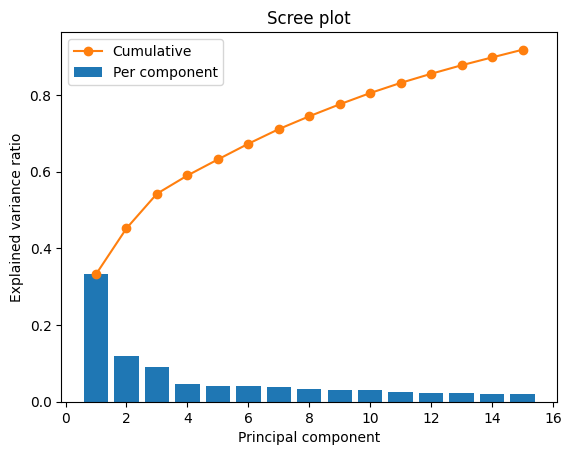

In [26]:
Xs = StandardScaler().fit_transform(X_train)

pca = PCA().fit(Xs)

cum = np.cumsum(pca.explained_variance_ratio_)

print(
    'Components for 90% variance:',
    np.argmax(cum >= 0.90) + 1,
    'of',
    X_train.shape[1]
)

plt.bar(
    range(1, 16),
    pca.explained_variance_ratio_[:15],
    label='Per component'
)

plt.plot(
    range(1, 16),
    cum[:15],
    'o-',
    color='C1',
    label='Cumulative'
)

plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.legend()
plt.title('Scree plot')
plt.show()

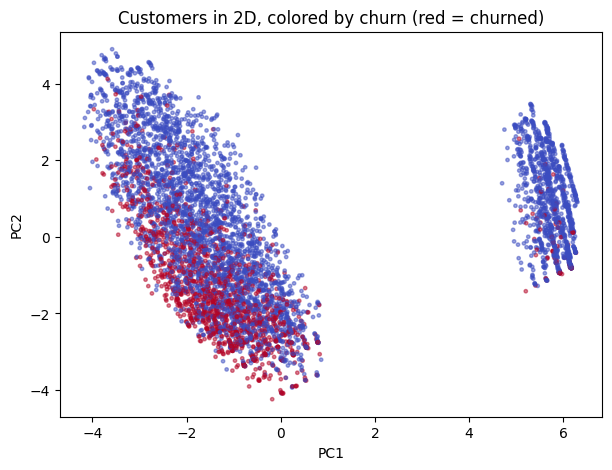

PC1 top loadings:
InternetService_No                      0.302
OnlineSecurity_No internet service      0.302
TechSupport_No internet service         0.302
StreamingTV_No internet service         0.302
DeviceProtection_No internet service    0.302
OnlineBackup_No internet service        0.302
dtype: float64


In [27]:
P = PCA(n_components=2).fit(Xs)

T = P.transform(Xs)

plt.figure(figsize=(7, 5))

plt.scatter(
    T[:, 0],
    T[:, 1],
    c=y_train,
    cmap='coolwarm',
    s=6,
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customers in 2D, colored by churn (red = churned)')
plt.show()

load = pd.Series(P.components_[0], index=X.columns)

print('PC1 top loadings:')

order = load.abs().sort_values(ascending=False).index

print(load.reindex(order).head(6).round(3))

In [28]:
candidates = {
    'LR (tuned C)': lr.set_params(
        model__C=Cs[va.mean(axis=1).argmax()]
    ),
    'RF (random search)': rs.best_estimator_,
    'XGBoost (tuned)': xs.best_estimator_,
}

rows = []

for name, m in candidates.items():
    cvs = cross_validate(
        m,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    rows.append({
        'model': name,
        'cv_auc': cvs['test_score'].mean(),
        'cv_std': cvs['test_score'].std()
    })

cmp = pd.DataFrame(rows)

print(cmp.round(4).to_string(index=False))

             model  cv_auc  cv_std
      LR (tuned C)  0.8464  0.0129
RF (random search)  0.8464  0.0114
   XGBoost (tuned)  0.8502  0.0117


In [29]:
best_name = cmp.loc[cmp['cv_auc'].idxmax(), 'model']
best = candidates[best_name].fit(X_train, y_train)

prob = best.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)

print(f'{best_name} on the test set (used once):')
print(f'AUC {roc_auc_score(y_test, prob):.4f}  '
      f'recall {recall_score(y_test, pred):.3f}  '
      f'precision {precision_score(y_test, pred):.3f}')

joblib.dump(best, 'churn_model.joblib')

XGBoost (tuned) on the test set (used once):
AUC 0.8483  recall 0.521  precision 0.659


['churn_model.joblib']

# Week 4 Lab 4: Package the Model and Test Serving

Run the notebook from the top using **Run All**. These cells are added after the Week 3 work and use its `df`, `X`, `best`, `cmp`, and `build_features` variables.


In [30]:
# Task 1.1: Save and inspect the final model
import json
import joblib
import sklearn
import numpy as np
import pandas as pd
import os

os.makedirs('/kaggle/working', exist_ok=True)
joblib.dump(best, '/kaggle/working/churn_model.joblib')
model = joblib.load('/kaggle/working/churn_model.joblib')

model_cols = list(model.feature_names_in_)
final_estimator = model[-1] if hasattr(model, 'steps') else model

print('Model:', type(final_estimator).__name__)
print('Feature columns:', len(model_cols))
print('scikit-learn version:', sklearn.__version__)


Model: XGBClassifier
Feature columns: 30
scikit-learn version: 1.6.1


In [31]:
# Task 1.2: Serving-time encoder (do not use drop_first=True here)
RAW_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]

def prepare_input(raw, columns):
    # Create dummy columns without dropping a category, then match training columns.
    encoded = pd.get_dummies(raw[RAW_COLS])
    return encoded.reindex(columns=columns, fill_value=0).astype(float)

print('Serving encoder is ready.')


Serving encoder is ready.


In [32]:
# Task 1.3: Reproduce the single-customer encoding bug
one = df[df['Contract'] == 'Two year'].head(1)

wrong = build_features(one).reindex(columns=model_cols, fill_value=0)
right = prepare_input(one, model_cols)

print('Contract columns, wrong:', wrong.filter(like='Contract').values)
print('Contract columns, right:', right.filter(like='Contract').values)
print(f'P(churn) wrong: {model.predict_proba(wrong)[0, 1]:.3f}')
print(f'P(churn) right: {model.predict_proba(right)[0, 1]:.3f}')


Contract columns, wrong: [[0 0]]
Contract columns, right: [[0. 1.]]
P(churn) wrong: 0.136
P(churn) right: 0.012


In [33]:
# Task 1.4: Parity test across all customers
raw = df.drop(columns=['Churn', 'customerID'], errors='ignore')
served = prepare_input(raw, model_cols)

p_train = model.predict_proba(X[model_cols])[:, 1]
p_serve = model.predict_proba(served)[:, 1]

largest_difference = np.abs(p_train - p_serve).max()
print('Largest difference:', largest_difference)
assert np.allclose(p_train, p_serve), 'Training-serving skew detected!'
print(f'Parity test passed on {len(raw)} customers')


Largest difference: 0.0
Parity test passed on 7043 customers


In [34]:
# Task 1.5: What-if analysis for the highest-risk customer
def what_if(model, row, columns, changes):
    baseline = model.predict_proba(prepare_input(row, columns))[0, 1]
    rows = []
    for feature, value in changes:
        alternative = row.copy()
        alternative[feature] = value
        probability = model.predict_proba(
            prepare_input(alternative, columns)
        )[0, 1]
        rows.append({
            'change': f'{feature} = {value}',
            'p_churn': round(probability, 3),
            'delta': round(probability - baseline, 3)
        })
    return baseline, pd.DataFrame(rows)

row = raw.iloc[[int(np.argmax(p_serve))]]
baseline, what_if_table = what_if(model, row, model_cols, [
    ('Contract', 'One year'),
    ('Contract', 'Two year'),
    ('PaymentMethod', 'Credit card (automatic)')
])
print(f'Baseline P(churn) = {baseline:.3f}')
display(what_if_table)


Baseline P(churn) = 0.935


,change,p_churn,delta
0,Contract = One year,0.862,-0.073
1,Contract = Two year,0.765,-0.170
2,PaymentMethod = Credit card (automatic),0.913,-0.022


In [35]:
# Task 1.6: Save metadata and 50 sample customers
best_cv = cmp.loc[cmp['model'] == best_name].iloc[0]
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

meta = {
    'model_name': type(final_estimator).__name__,
    'sklearn_version': sklearn.__version__,
    'feature_columns': model_cols,
    'threshold': 0.30,
    'cv_auc': float(best_cv['cv_auc']),
    'cv_auc_std': float(best_cv['cv_std']),
    'test_auc': float(test_auc),
    'training_data': 'IBM Telco Customer Churn',
    'version': '1.0'
}

with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

sample = df.drop(columns=['Churn', 'customerID'], errors='ignore').sample(
    50, random_state=1
)
sample.to_csv('/kaggle/working/sample_customers.csv', index=False)

print('Saved: /kaggle/working/churn_model.joblib')
print('Saved: /kaggle/working/model_meta.json')
print('Saved: /kaggle/working/sample_customers.csv')
print('Actual CV AUC:', round(meta['cv_auc'], 4))
print('Actual CV AUC std:', round(meta['cv_auc_std'], 4))
print('Actual test AUC:', round(meta['test_auc'], 4))


Saved: /kaggle/working/churn_model.joblib
Saved: /kaggle/working/model_meta.json
Saved: /kaggle/working/sample_customers.csv
Actual CV AUC: 0.8502
Actual CV AUC std: 0.0117
Actual test AUC: 0.8483
